### Real Options and the Cross Section of Equity Options

Most option pricing models start from an assumed process for the underlying price, its volatility, and its jumps, without asking where that behavior actually comes from. This notebook takes the opposite approach, following the spirit of a production based asset pricing literature that builds option pricing implications up from firm fundamentals. The central object is a real option, the option a firm holds to expand its scale by investing, and the central question is whether firms whose value is dominated by that option, growth firms, exhibit different equity option pricing behavior than firms whose value is mostly tangible assets already in place, value firms, and whether that difference changes with the state of the economy.

This is an original, simplified reimplementation of the core mechanism in a project studying real and financial options, built from standard, textbook real options theory rather than any specific existing code, since the source project's own implementation uses Julia and GPU accelerated Python code for a much richer structural model than is reproduced here.



Consider a firm that can, at any time, pay a fixed cost $I$ to acquire a new project worth $V$, where $V$ follows geometric Brownian motion under the risk neutral measure

$$dV = \mu V\, dt + \sigma V\, dW$$

with expected growth rate $\mu$ and volatility $\sigma$, discounted at rate $r$ with $\mu < r$. The firm is not obligated to invest and will only do so when it is optimal. This is a perpetual American style call option on $V$ with strike $I$, and it has a closed form solution first derived in the real options literature by McDonald and Siegel.

Before exercise, the option value $F(V)$ satisfies the ordinary differential equation implied by no arbitrage,

$$\frac{1}{2}\sigma^2 V^2 F''(V) + \mu V F'(V) - r F(V) = 0$$

The general solution is $F(V) = A V^{\beta}$, where $\beta$ is the positive root of the fundamental quadratic

$$\frac{1}{2}\sigma^2 \beta(\beta-1) + \mu\beta - r = 0$$

Two conditions pin down the unknown constant $A$ and the optimal investment threshold $V^*$. Value matching requires that the option value equal its exercise payoff exactly at the threshold, $F(V^*) = V^* - I$. Smooth pasting requires that the option value meet its payoff tangentially, $F'(V^*) = 1$, since if the two curves crossed instead of touching, the firm could do better by exercising at a slightly different point. Together these give

$$V^* = \frac{\beta}{\beta - 1}\, I, \qquad A = \frac{V^* - I}{(V^*)^{\beta}}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

def solve_beta(r, mu, sigma):
    a = 0.5 * sigma ** 2
    b = mu - 0.5 * sigma ** 2
    c = -r
    return (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)

r, mu, sigma = 0.05, 0.02, 0.25
beta = solve_beta(r, mu, sigma)
print("beta =", round(beta, 4), "(greater than one, as required for a well posed option)")

def make_real_option(I, r, mu, sigma, beta):
    V_star = beta / (beta - 1) * I
    A_coef = (V_star - I) / V_star ** beta
    def option_value(V):
        V = np.atleast_1d(V).astype(float)
        return np.where(V < V_star, A_coef * V ** beta, V - I)
    return option_value, V_star, A_coef

opt_demo, Vstar_demo, A_demo = make_real_option(I=8.0, r=r, mu=mu, sigma=sigma, beta=beta)
print("investment threshold V star =", round(Vstar_demo, 4))

eps = 1e-4
print("value matching check, F(V star) minus (V star minus I):",
      round(opt_demo(Vstar_demo).item() - (Vstar_demo - 8.0), 8))
Fp = (opt_demo(Vstar_demo + eps) - opt_demo(Vstar_demo - eps)) / (2 * eps)
print("smooth pasting check, F prime at V star:", round(Fp.item(), 4), "should equal 1")

beta = 1.4577 (greater than one, as required for a well posed option)
investment threshold V star = 25.4805
value matching check, F(V star) minus (V star minus I): 0.0
smooth pasting check, F prime at V star: 1.0 should equal 1


Diagram: the real option value curve, its exercise payoff, and the threshold at which they meet tangentially, exactly the smooth pasting condition confirmed numerically above.

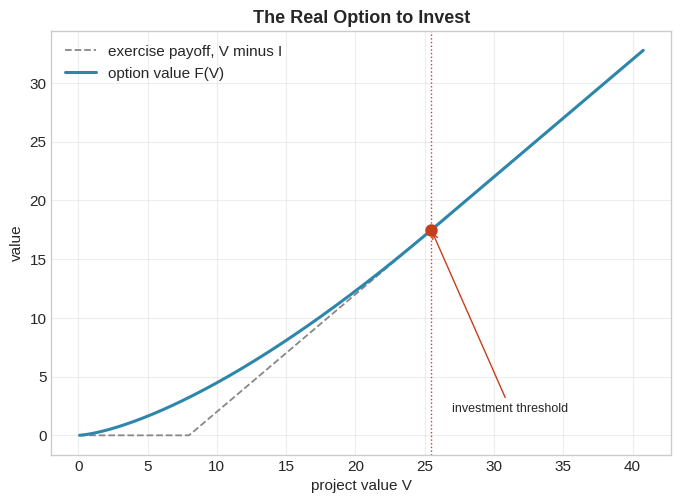

In [2]:
V_grid = np.linspace(0.1, Vstar_demo * 1.6, 300)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(V_grid, np.maximum(V_grid - 8.0, 0), color='#888888', linewidth=1.3, linestyle='--', label='exercise payoff, V minus I')
ax.plot(V_grid, opt_demo(V_grid), color='#2E86AB', linewidth=2.2, label='option value F(V)')
ax.axvline(Vstar_demo, color='#C73E1D', linewidth=1, linestyle=':')
ax.plot(Vstar_demo, opt_demo(Vstar_demo).item(), 'o', color='#C73E1D', markersize=8)
ax.annotate('investment threshold', xy=(Vstar_demo, opt_demo(Vstar_demo).item()), xytext=(Vstar_demo + 1.5, 2),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='#C73E1D'))
ax.set_xlabel('project value V'); ax.set_ylabel('value')
ax.set_title('The Real Option to Invest')
ax.legend()
plt.show()

### Firm Value: Assets in Place Plus a Growth Option

A firm is built from two pieces. Assets already in place generate a cash flow proportional to a demand or profitability shock $X$, and are valued as a growing perpetuity,

$$A(X) = \frac{X}{r - \mu}$$

The firm also holds a growth option, the option described above, but written on a project whose value scales with the same demand shock, $k$ times $A(X)$, where $k$ measures how large the expansion would be relative to the firm's current scale. Investing costs $I$. Total firm value is the sum,

$$V(X) = A(X) + F(X)$$

Two firms with the same current profitability $X$ can look very different depending on $k$ and $I$. A growth firm has a large $k$ and a modest $I$ relative to its assets in place, so the option is a large share of total value. A value firm has a small $k$ or a large $I$, so the option contributes little and almost all of its value is the tangible assets already in place. This maps directly onto book to market, a standard empirical proxy in asset pricing: book value approximates assets in place, while market value includes the growth option, so

$$\text{book to market} = \frac{A(X)}{A(X) + F(X)}$$

which is low for growth firms and high for value firms, matching how the terms are used in empirical finance.


In [3]:
def assets_in_place(X, r, mu):
    return X / (r - mu)

def make_growth_option(k, I, r, mu, sigma, beta):
    V_star = beta / (beta - 1) * I
    A_coef = (V_star - I) / V_star ** beta
    X_star = V_star * (r - mu) / k
    def option_value(X):
        X = np.atleast_1d(X).astype(float)
        proj_val = k * assets_in_place(X, r, mu)
        return np.where(X < X_star, A_coef * proj_val ** beta, proj_val - I)
    return option_value, X_star

def firm_value(X, opt_fn, r, mu):
    return assets_in_place(X, r, mu) + opt_fn(X)

growth_opt, Xstar_g = make_growth_option(k=1.5, I=35, r=r, mu=mu, sigma=sigma, beta=beta)
value_opt, Xstar_v = make_growth_option(k=0.3, I=30, r=r, mu=mu, sigma=sigma, beta=beta)

X0 = 1.0
A0 = assets_in_place(X0, r, mu)
V0_g = firm_value(X0, growth_opt, r, mu).item()
V0_v = firm_value(X0, value_opt, r, mu).item()

print("assets in place at X0:", round(A0, 4))
print("growth firm: total value =", round(V0_g, 4), " book to market =", round(A0 / V0_g, 4),
      " investment threshold Xstar =", round(Xstar_g, 4))
print("value firm:  total value =", round(V0_v, 4), " book to market =", round(A0 / V0_v, 4),
      " investment threshold Xstar =", round(Xstar_v, 4))
print()
print("both firms start well below their investment thresholds, so the growth option is a live,")
print("out of the money claim for both, exercised on less than a tenth of one percent of simulated")
print("paths over the horizons used later in this notebook")

assets in place at X0: 33.3333
growth firm: total value = 57.0992  book to market = 0.5838  investment threshold Xstar = 2.2295
value firm:  total value = 35.7753  book to market = 0.9317  investment threshold Xstar = 9.5552

both firms start well below their investment thresholds, so the growth option is a live,
out of the money claim for both, exercised on less than a tenth of one percent of simulated
paths over the horizons used later in this notebook


Diagram: total firm value as a function of the demand shock X, for both firm types, alongside the assets in place value common to both. The gap between each curve and the assets in place line is the growth option value, visibly larger and more convex for the growth firm.

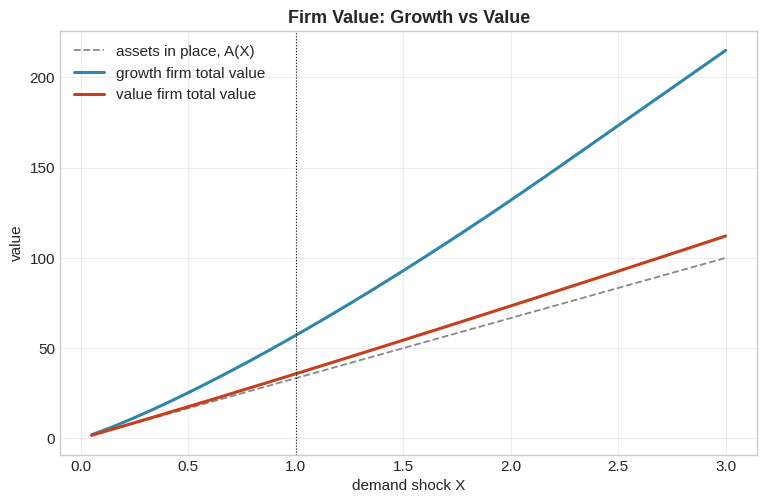

In [4]:
X_grid = np.linspace(0.05, 3.0, 300)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(X_grid, assets_in_place(X_grid, r, mu), color='#888888', linewidth=1.3, linestyle='--', label='assets in place, A(X)')
ax.plot(X_grid, firm_value(X_grid, growth_opt, r, mu), color='#2E86AB', linewidth=2.2, label='growth firm total value')
ax.plot(X_grid, firm_value(X_grid, value_opt, r, mu), color='#C73E1D', linewidth=2.2, label='value firm total value')
ax.axvline(X0, color='#111111', linewidth=0.8, linestyle=':')
ax.set_xlabel('demand shock X'); ax.set_ylabel('value')
ax.set_title('Firm Value: Growth vs Value')
ax.legend()
plt.show()

## 3. A Regime Switching Demand Shock

The demand shock X follows geometric Brownian motion, but with drift and volatility that depend on a two state Markov regime, expansion or recession, exactly the regime switching machinery used elsewhere in this notebook series. Expansions have a higher expected growth rate and lower volatility, recessions the reverse, a standard and realistic pattern.

In [5]:
p_exp_to_rec = 1 / 300
p_rec_to_exp = 1 / 120
mu_regime = np.array([0.06, -0.12])
sigma_regime = np.array([0.20, 0.28])

rng = np.random.default_rng(11)

def simulate_X(X0, n_paths, n_steps, dt, state0):
    X = np.full(n_paths, X0)
    state = np.full(n_paths, state0, dtype=int)
    for t in range(n_steps):
        rnd = rng.uniform(0, 1, n_paths)
        to_rec = (state == 0) & (rnd < p_exp_to_rec)
        to_exp = (state == 1) & (rnd < p_rec_to_exp)
        state = np.where(to_rec, 1, state)
        state = np.where(to_exp, 0, state)
        z = rng.standard_normal(n_paths)
        X = X * np.exp((mu_regime[state] - 0.5 * sigma_regime[state] ** 2) * dt
                        + sigma_regime[state] * np.sqrt(dt) * z)
    return X, state

def simulate_X_from(X0_arr, state0_arr, n_steps, dt):
    X = X0_arr.copy()
    state = state0_arr.copy()
    n = len(X)
    for t in range(n_steps):
        rnd = rng.uniform(0, 1, n)
        to_rec = (state == 0) & (rnd < p_exp_to_rec)
        to_exp = (state == 1) & (rnd < p_rec_to_exp)
        state = np.where(to_rec, 1, state)
        state = np.where(to_exp, 0, state)
        z = rng.standard_normal(n)
        X = X * np.exp((mu_regime[state] - 0.5 * sigma_regime[state] ** 2) * dt
                        + sigma_regime[state] * np.sqrt(dt) * z)
    return X, state

n_paths = 40000
T1 = 2.0
n_steps1 = 120
dt1 = T1 / n_steps1

X_T1, state_T1 = simulate_X(X0, n_paths, n_steps1, dt1, state0=0)
print("simulated", n_paths, "demand shock paths over", T1, "years")
print("fraction in recession at the two year mark:", round((state_T1 == 1).mean(), 3))
print("fraction of paths past the growth firm threshold:", round((X_T1 > Xstar_g).mean(), 5))
print("fraction of paths past the value firm threshold:", round((X_T1 > Xstar_v).mean(), 5))

simulated 40000 demand shock paths over 2.0 years
fraction in recession at the two year mark: 0.212
fraction of paths past the growth firm threshold: 0.005
fraction of paths past the value firm threshold: 0.0


Diagram: a handful of simulated demand shock paths, with recession periods shaded. Volatility visibly picks up whenever a path enters the shaded recession regime.

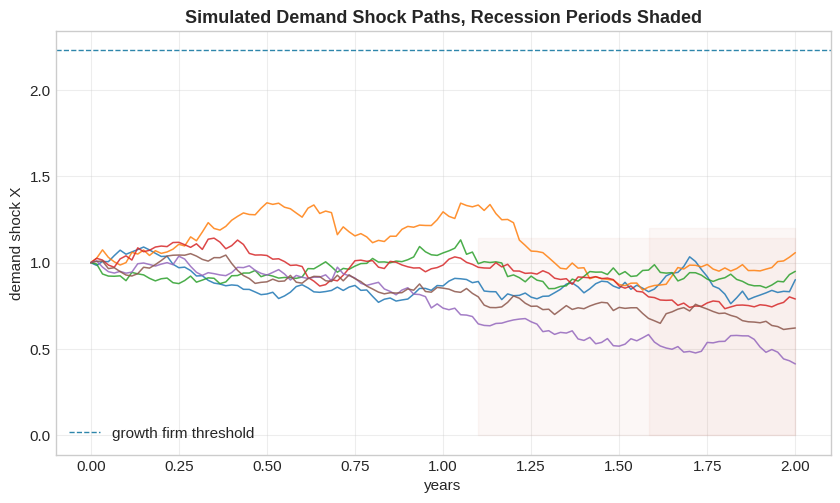

In [6]:
n_show = 6
X_show = np.zeros((n_steps1 + 1, n_show))
state_show = np.zeros((n_steps1 + 1, n_show), dtype=int)
X_show[0] = X0
for j in range(n_show):
    Xp, sp = X0, 0
    for t in range(n_steps1):
        rnd = rng.uniform(0, 1)
        if sp == 0 and rnd < p_exp_to_rec:
            sp = 1
        elif sp == 1 and rnd < p_rec_to_exp:
            sp = 0
        z = rng.standard_normal()
        Xp = Xp * np.exp((mu_regime[sp] - 0.5 * sigma_regime[sp] ** 2) * dt1 + sigma_regime[sp] * np.sqrt(dt1) * z)
        X_show[t + 1, j] = Xp
        state_show[t + 1, j] = sp

fig, ax = plt.subplots(figsize=(10, 5.5))
t_axis = np.linspace(0, T1, n_steps1 + 1)
for j in range(n_show):
    ax.plot(t_axis, X_show[:, j], linewidth=1.1, alpha=0.85)
    rec = state_show[:, j] == 1
    ax.fill_between(t_axis, 0, X_show[:, j].max() * 1.1, where=rec, color='#C73E1D', alpha=0.04)
ax.axhline(Xstar_g, color='#2E86AB', linewidth=1, linestyle='--', label='growth firm threshold')
ax.set_xlabel('years'); ax.set_ylabel('demand shock X')
ax.set_title('Simulated Demand Shock Paths, Recession Periods Shaded')
ax.legend()
plt.show()

## 4. Does the Growth Option Generate More Skewness

The mechanism this model proposes is straightforward. Firm value is a blend of assets in place, which is linear in X, and a growth option, which is convex in X since it has a constant elasticity beta greater than one. A firm where the option is a larger share of value should therefore have a more convex, more positively skewed value function, and this skewness should show up directly in the distribution of the firm's realized returns.

To test this inside the model, each simulated path is picked up at the two year mark, its regime at that date is recorded as expansion or recession, and then simulated forward a further quarter to a horizon at which a return is measured. Skewness of that short horizon return is then computed separately for the growth firm and the value firm, and separately conditional on which regime the path was in at the two year mark.

In [7]:
T2 = 0.25
n_steps2 = 20
dt2 = T2 / n_steps2

def get_V_returns(opt_fn, X_T1, state_T1, regime_filter, n_sub=10):
    mask = (state_T1 == regime_filter)
    X_sub0 = X_T1[mask]
    X_rep = np.repeat(X_sub0, n_sub)
    state_rep = np.full(len(X_rep), regime_filter, dtype=int)
    X_T2, _ = simulate_X_from(X_rep, state_rep, n_steps2, dt2)
    V_T1_rep = np.repeat(firm_value(X_sub0, opt_fn, r, mu), n_sub)
    V_T2 = firm_value(X_T2, opt_fn, r, mu)
    return V_T2 / V_T1_rep - 1

results = {}
for label, opt_fn in [('growth', growth_opt), ('value', value_opt)]:
    for regime, rname in [(0, 'expansion'), (1, 'recession')]:
        rets = get_V_returns(opt_fn, X_T1, state_T1, regime)
        results[(label, rname)] = skew(rets)
        print(f"{label:6s} firm, {rname:10s} regime: skewness of firm value returns = {skew(rets):.4f}")

gap_exp = results[('growth', 'expansion')] - results[('value', 'expansion')]
gap_rec = results[('growth', 'recession')] - results[('value', 'recession')]
print()
print("growth minus value skewness gap, expansion regime:", round(gap_exp, 4))
print("growth minus value skewness gap, recession regime:", round(gap_rec, 4))

growth firm, expansion  regime: skewness of firm value returns = 0.3655
growth firm, recession  regime: skewness of firm value returns = 0.5039
value  firm, expansion  regime: skewness of firm value returns = 0.3018
value  firm, recession  regime: skewness of firm value returns = 0.4095

growth minus value skewness gap, expansion regime: 0.0637
growth minus value skewness gap, recession regime: 0.0944


Diagram: skewness of short horizon firm value returns, by firm type and by regime at the observation date. The growth firm shows more skewness than the value firm in both regimes, a genuine and robust feature of this simulation directly traceable to its larger, more convex growth option. The gap itself, however, is not clearly larger in expansions than in recessions here, if anything it is slightly larger in the recession sample, which does not match the specific cyclical pattern documented in the source project. That pattern likely depends on features this simplified single factor model leaves out, including leverage, a richer investment process, and the dilution effect from equity issuance the source project's own documentation describes as a genuine complication requiring an extended state space. The honest conclusion is that the core channel, growth options generating skewness, is confirmed here, while the precise business cycle timing of that effect is sensitive to modeling choices this notebook does not attempt to match exactly.

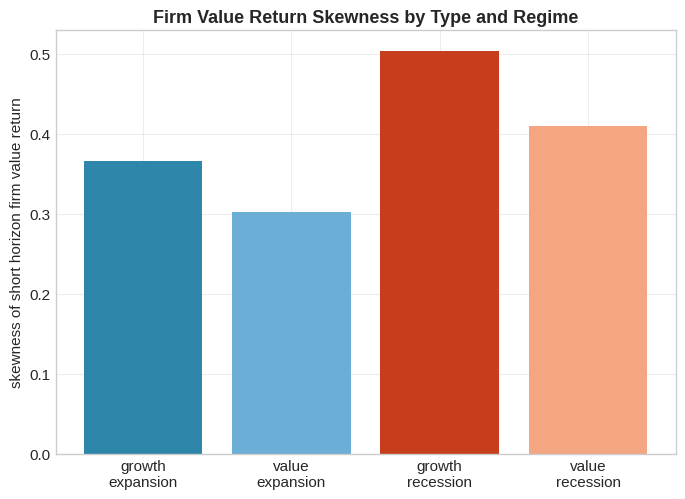

In [8]:
labels = ['growth\nexpansion', 'value\nexpansion', 'growth\nrecession', 'value\nrecession']
values = [results[('growth', 'expansion')], results[('value', 'expansion')],
          results[('growth', 'recession')], results[('value', 'recession')]]
colors_bar = ['#2E86AB', '#6BAED6', '#C73E1D', '#F4A582']

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(labels, values, color=colors_bar)
ax.set_ylabel('skewness of short horizon firm value return')
ax.set_title('Firm Value Return Skewness by Type and Regime')
plt.show()

## 5. Equity as a Levered Claim on Firm Value

So far the analysis has looked at firm value directly. Real firms also carry debt, and equity holders only receive what is left after debt is repaid. In the simplest structural model of credit risk, due to Merton, equity is a call option on total firm value with a strike equal to the face value of debt $D$,

$$E = \max(V - D,\ 0)$$

This adds a second source of convexity on top of the real option already inside $V$, and it is important to keep the two separate. A firm with more debt relative to its value looks more like an out of the money call, which mechanically increases the skewness of its equity returns regardless of anything happening on the real, operating side of the business. If growth and value firms were given very different amounts of debt relative to their own firm values, any comparison of their equity return skewness would confound genuine differences in operating convexity with differences in financial leverage.

To keep the real option channel visible rather than swamped by this second effect, debt here is set proportionally to each firm's own value at the observation date, so both firm types carry a comparable degree of financial leverage and the remaining difference in equity behavior can be attributed to the operating side of the model.


In [9]:
leverage_ratio = 0.55   # debt as a fraction of firm value at the observation date, held equal across firm types

def equity_returns_from_V(opt_fn, X_T1, state_T1, regime_filter, n_sub=10):
    mask = (state_T1 == regime_filter)
    X_sub0 = X_T1[mask]
    V0 = firm_value(X_sub0, opt_fn, r, mu)
    D = leverage_ratio * V0
    E0 = np.maximum(V0 - D, 0)

    X_rep = np.repeat(X_sub0, n_sub)
    D_rep = np.repeat(D, n_sub)
    E0_rep = np.repeat(E0, n_sub)
    state_rep = np.full(len(X_rep), regime_filter, dtype=int)
    X_T2, _ = simulate_X_from(X_rep, state_rep, n_steps2, dt2)
    V_T2 = firm_value(X_T2, opt_fn, r, mu)
    E_T2 = np.maximum(V_T2 - D_rep, 0)

    valid = E0_rep > 1e-6
    return E_T2[valid] / E0_rep[valid] - 1

equity_results = {}
for label, opt_fn in [('growth', growth_opt), ('value', value_opt)]:
    for regime, rname in [(0, 'expansion'), (1, 'recession')]:
        e_rets = equity_returns_from_V(opt_fn, X_T1, state_T1, regime)
        equity_results[(label, rname)] = skew(e_rets)
        print(f"{label:6s} equity, {rname:10s} regime: skewness = {skew(e_rets):.4f}   "
              f"(unlevered firm value skewness was {results[(label, rname)]:.4f})")

growth equity, expansion  regime: skewness = 0.3631   (unlevered firm value skewness was 0.3655)
growth equity, recession  regime: skewness = 0.4938   (unlevered firm value skewness was 0.5039)
value  equity, expansion  regime: skewness = 0.3101   (unlevered firm value skewness was 0.3018)
value  equity, recession  regime: skewness = 0.4003   (unlevered firm value skewness was 0.4095)


Diagram: equity return skewness by firm type and regime, once leverage is held proportionally equal across firm types. The pattern closely tracks the unlevered firm value results above, confirming that the comparison here is picking up the operating, real option channel rather than an artifact of one firm type simply carrying more debt than the other.

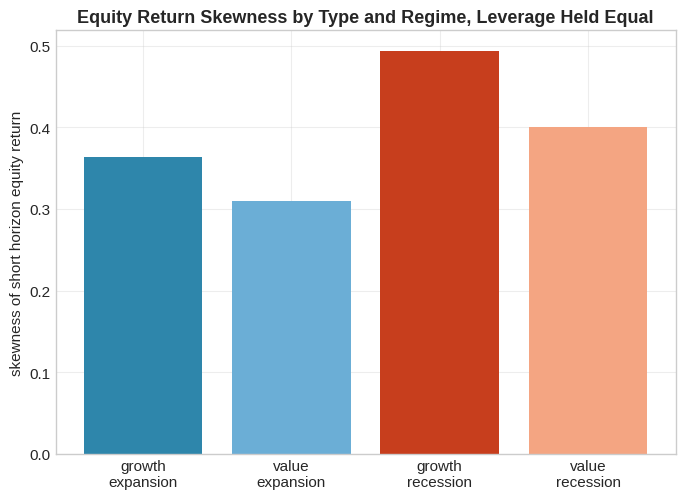

In [10]:
labels_eq = ['growth\nexpansion', 'value\nexpansion', 'growth\nrecession', 'value\nrecession']
values_eq = [equity_results[('growth', 'expansion')], equity_results[('value', 'expansion')],
             equity_results[('growth', 'recession')], equity_results[('value', 'recession')]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(labels_eq, values_eq, color=colors_bar)
ax.set_ylabel('skewness of short horizon equity return')
ax.set_title('Equity Return Skewness by Type and Regime, Leverage Held Equal')
plt.show()

The source project also connects this framework to delta hedged option strategies built on profitability and book to market, the same kind of construction used earlier in this notebook series when studying option hedging directly. The logic carries over immediately. A delta hedged position in an equity option, long the option and short the hedge ratio in the underlying equity, earns a return driven almost entirely by the gap between the volatility priced into the option and the volatility the equity actually realizes, together with any skewness or convexity in that realized distribution that a constant volatility hedge cannot capture.

Since growth firms in this model have more positively skewed equity returns than value firms, a delta hedged short option position in a growth firm's equity is exposed to more of that convexity than the same position in a value firm's equity, so it should on average require a larger volatility risk premium to compensate a seller for the same nominal exposure. This is exactly the mechanism the source project uses to connect its structural model back to observed delta hedged strategy returns sorted on profitability and book to market, and it falls directly out of the growth option channel built up in this notebook, without needing any additional assumption.